# **Quark-Gluon Jet Tagging with Graph Neural Networks**
GSoC Task II — Classical GNN Implementation\
Author: Rohit | Mail: rchiluka1612@gmail.com\
Dataset: Zenodo 3164691 — Pythia8 Q/G Jets\
Models: ParticleNet (DynamicEdgeConv) vs JetGAT (GATv2)

**What this notebook does**\
This notebook implements and compares two Graph Neural Network architectures for classifying particle jets as originating from Quarks or Gluons — a fundamental discrimination problem in experimental particle physics at the Large Hadron Collider (LHC).

**The Physics Problem**\
When two protons collide at the LHC, quarks and gluons are knocked out and immediately spray into hundreds of particles called a jet. The goal is to identify whether a jet originated from a quark or a gluon using only the kinematic properties of its constituent particles.

**Why this is hard**\
Quark and gluon jets look similar but differ statistically:\
Quark jets — narrow, concentrated, fewer particles, harder energy core\
Gluon jets — broad, diffuse, more particles, softer radiation spread

No single particle tells you the answer. The classifier must learn the collective pattern across the whole jet.

**Why Graph Neural Networks**\
A jet is an unordered set of particles — variable in size, meaningless in sequence. GNNs are the natural choice because they:

Handle permutation invariance natively (particle order doesn't matter)\
Process variable-length inputs without padding tricks\
Preserve exact kinematic precision (no pixelation like CNNs)




**Section 1 — Environment Setup**

**1.1 Working Directory**

Google Colab starts in /root. We move to /content first to ensure all relative paths and Drive mounts work correctly. This must be the very first cell executed every session.

In [ ]:
import os
os.chdir('/content')
print(os.getcwd())  # should print /content

/content


**1.2 Mount Google Drive**

All persistent data lives on Google Drive — checkpoints, logs, dataset cache, and source files. This means training can be interrupted and resumed without losing any progress.
After mounting, the project structure lives at:

```
/content/drive/MyDrive/jet_gnn/

├── src/              ← Python source files (models, trainer, data_loader)
├── checkpoints/      ← Saved model weights (.pt files)
├── logs/             ← Training history in JSON format
├── results/          ← All evaluation plots (PNG)
├── graphs_cache/     ← Pre-built PyG graphs (skip rebuild every session)
└── energyflow_cache/ ← Raw Zenodo dataset files (.npz)
```



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**1.3 Verify GPU**

We confirm a T4 GPU is available. Mixed-precision training (FP16) requires CUDA, and the PyG wheel URLs depend on the exact CUDA version.

Expected output:

PyTorch : 2.x.x+cu128\
CUDA    : 11.8\
GPU     : Tesla T4

If GPU shows NOT FOUND, go to Runtime → Change runtime type → T4 GPU.

In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND"}')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4


**1.4 Build PyG Wheel URL**

PyTorch Geometric's dependencies (torch_scatter, torch_sparse, etc.) are not on PyPI — they are pre-compiled CUDA binaries hosted on PyG's own wheel server.

The download URL encodes the exact PyTorch + CUDA version combination.\
For example: https://data.pyg.org/whl/torch-2.1.0+cu118.html

We build this URL programmatically so it always matches the current Colab environment regardless of which PyTorch version Colab ships.

In [ ]:
import torch, os
os.chdir('/content')

TORCH = torch.__version__.split('+')[0]
CUDA  = torch.version.cuda.replace('.', '')
url   = f'https://data.pyg.org/whl/torch-{TORCH}+cu{CUDA}.html'

print(f'Installing for torch={TORCH}, cuda={CUDA}')
print(f'Wheel URL: {url}')

Installing for torch=2.10.0, cuda=128
Wheel URL: https://data.pyg.org/whl/torch-2.10.0+cu128.html


**1.5 Pin NumPy to 1.26.4**

Critical step — must run before installing PyG.
PyG's pre-compiled CUDA wheels were built against NumPy 1.x. Colab's default NumPy is 2.x. Without pinning, importing torch_scatter raises:

```
ValueError: numpy.dtype size changed, may indicate binary incompatibility.
Expected 96 from C header, got 88 from PyObject
```


This is a C-level struct size mismatch between the compiled extension and the installed NumPy. The only fix is pinning NumPy before installation.

After running this cell, restart the runtime via Runtime → Restart, then continue from the next cell

In [ ]:
!pip install -q numpy==1.26.4 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you ha

**1.6 Install PyTorch Geometric and Dependencies**

PyG is installed in two steps:

Step 1 — Core library from PyPI (pure Python):

```
torch_geometric
```
Step 2 — Four compiled C++/CUDA extensions from PyG's wheel server:

```
Package             Role in GNN operations
torch_scatter       Efficient scatter operations used in every message passing step
torch_sparse        Sparse matrix ops for adjacency matrix representations
torch_cluster       Builds k-NN graphs during data loading
torch_spline_conv   Spline-based convolution (required dependency)

```
Each package is installed separately so errors are easy to identify. Installing all at once with one pip command can silently fail on one package.


In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


In [ ]:
!pip install torch_scatter -f {url}

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 70.8 MB/s eta 0:00:00


In [ ]:
!pip install torch_sparse -f {url}

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 26.3 MB/s eta 0:00:00


In [ ]:
!pip install torch_cluster -f {url}

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 36.2 MB/s eta 0:00:00


In [ ]:
!pip install torch_spline_conv -f {url}

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.8 MB/s eta 0:00:00


**1.7 Install Data and Evaluation Packages**

*  ```energyflow ``` — provides programmatic access to the Zenodo-3164691 Q/G jet dataset with automatic download and MD5 checksum verification
*   ```scikit-learn ``` — used for AUC computation (roc_auc_score) and confusion matrices during evaluation

In [ ]:
!pip install energyflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.2/503.2 kB 16.1 MB/s eta 0:00:00


In [ ]:
# Verify all installations
import torch
print(f'PyTorch        : {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'GPU            : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT FOUND"}')

import torch_geometric
print(f'PyG            : {torch_geometric.__version__}')

import torch_scatter
print(f'torch_scatter  : {torch_scatter.__version__}')

import torch_sparse
print(f'torch_sparse   : {torch_sparse.__version__}')

import torch_cluster
print(f'torch_cluster  : {torch_cluster.__version__}')

import energyflow
print(f'energyflow     : {energyflow.__version__}')

import sklearn
print(f'scikit-learn   : {sklearn.__version__}')

print('\n✔ All packages verified')

PyTorch        : 2.10.0+cu128
CUDA available : True
GPU            : Tesla T4
PyG            : 2.7.0
torch_scatter  : 2.1.2+pt210cu128
torch_sparse   : 0.6.18+pt210cu128
torch_cluster  : 1.6.3+pt210cu128
energyflow     : 1.4.0
scikit-learn   : 1.6.1

✔ All packages verified


# Section 2 — Source Files
All source code is written directly to Google Drive using `%%writefile`. This means every file persists across sessions — if the runtime resets, the code is still there and does not need to be rewritten.

**2.1 Check Project Directory**

Verifies the symlink from /content/jet_gnn → Drive source directory exists. A missing symlink means the runtime reset and needs to be recreated (handled in a recovery cell later in the notebook).

In [ ]:
import os
print(os.path.exists('/content/jet_gnn'))
print(os.listdir('/content/jet_gnn'))

True
['models']


In [ ]:
%%writefile /content/jet_gnn/models/__init__.py
from .particle_net import ParticleNet
from .jet_gat import JetGAT

Overwriting /content/jet_gnn/models/__init__.py


In [ ]:
%%writefile /content/jet_gnn/data_loader.py
import numpy as np
import torch
import pickle
from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.nn import knn_graph
import energyflow as ef

# ── Constants ──────────────────────────────────────────────────────────────────
K_NEIGHBORS   = 16
MAX_PARTICLES = 150
N_PER_CLASS   = 50_000   # 50k quarks + 50k gluons = 100k total
TRAIN_FRAC    = 0.70
VAL_FRAC      = 0.15

PDG_MAP = {
    22:0,
    211:1,  -211:1,
    321:2,  -321:2,
    2212:3, -2212:3,
    130:4,
    11:5,   -11:5,
    13:6,   -13:6,
    2112:7, -2112:7,
}
N_PDG = len(set(PDG_MAP.values())) + 1

def encode_pdg(p):
    return PDG_MAP.get(int(p), N_PDG - 1)

# ── Graph builder ──────────────────────────────────────────────────────────────
def jet_to_graph(particles):
    mask      = particles[:, 0] > 0
    particles = particles[mask][:MAX_PARTICLES]
    if len(particles) == 0:
        return None
    n = len(particles)

    pt    = particles[:, 0]
    eta   = particles[:, 1]
    phi   = particles[:, 2]
    pdgid = particles[:, 3]

    jet_pt   = pt.sum() + 1e-8
    E_approx = pt * np.cosh(eta)
    jet_eta  = np.sum(pt * eta) / jet_pt
    jet_phi  = np.sum(pt * phi) / jet_pt

    pt_rel  = pt / jet_pt
    eta_rel = eta - jet_eta
    phi_rel = phi - jet_phi
    phi_rel = (phi_rel + np.pi) % (2 * np.pi) - np.pi
    log_pt  = np.log(pt + 1e-8)
    log_E   = np.log(E_approx + 1e-8)
    pdg_enc = np.array([encode_pdg(p) / N_PDG for p in pdgid])

    x = torch.tensor(
        np.stack([pt_rel, eta_rel, phi_rel,
                  log_pt, log_E, pdg_enc], axis=1).astype(np.float32)
    )

    coords     = torch.tensor(
        np.stack([eta_rel, phi_rel], axis=1).astype(np.float32)
    )
    k          = min(K_NEIGHBORS, n - 1)
    edge_index = knn_graph(coords, k=k, loop=False)

    src, dst = edge_index
    d_eta  = eta_rel[src.numpy()] - eta_rel[dst.numpy()]
    d_phi  = phi_rel[src.numpy()] - phi_rel[dst.numpy()]
    d_phi  = (d_phi + np.pi) % (2 * np.pi) - np.pi
    dR     = np.sqrt(d_eta**2 + d_phi**2 + 1e-8)
    kt     = np.minimum(pt[src.numpy()], pt[dst.numpy()]) * dR
    log_kt = np.log(kt + 1e-8)

    edge_attr = torch.tensor(
        np.stack([d_eta, d_phi, dR, log_kt], axis=1).astype(np.float32)
    )

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# ── Dataset loader ─────────────────────────────────────────────────────────────
def load_dataset(n_per_class=N_PER_CLASS, seed=42,
                 graphs_cache_dir=None, ef_cache_dir=None):

    tag      = f"balanced_n{n_per_class}_s{seed}"
    ef_cache = str(ef_cache_dir) if ef_cache_dir else "~/.energyflow"

    # ── Load from graph cache if exists ───────────────────────────────────────
    if graphs_cache_dir is not None:
        cache_file = Path(graphs_cache_dir) / f"{tag}.pkl"
        if cache_file.exists():
            print(f"[data_loader] Loading from cache: {cache_file}")
            with open(cache_file, "rb") as f:
                train, val, test = pickle.load(f)
            print(f"[data_loader] train={len(train):,}  "
                  f"val={len(val):,}  test={len(test):,}")
            return train, val, test

    # ── Download from EnergyFlow ───────────────────────────────────────────────
    print(f"[data_loader] Downloading dataset ...")
    print(f"[data_loader] Loading 100,000 jets (pythia, no b/c)")

    X, y = ef.qg_jets.load(
        num_data  = 100_000,
        pad       = True,
        generator = 'pythia',
        with_bc   = False,
        cache_dir = ef_cache,
    )

    print(f"[data_loader] Raw dataset shape : X={X.shape}  y={y.shape}")
    print(f"[data_loader] Quarks in raw     : {(y==1).sum():,}")
    print(f"[data_loader] Gluons in raw     : {(y==0).sum():,}")

    # ── Balanced sampling ─────────────────────────────────────────────────────
    q_idx = np.where(y == 1)[0][:n_per_class]
    g_idx = np.where(y == 0)[0][:n_per_class]

    X_q = X[q_idx]
    X_g = X[g_idx]

    print(f"[data_loader] Sampled quarks    : {len(X_q):,}")
    print(f"[data_loader] Sampled gluons    : {len(X_g):,}")

    X_all = np.concatenate([X_q, X_g], axis=0)
    y_all = np.array(
        [1] * len(X_q) + [0] * len(X_g),
        dtype=np.int64
    )

    # ── Shuffle ───────────────────────────────────────────────────────────────
    rng   = np.random.default_rng(seed)
    perm  = rng.permutation(len(y_all))
    X_all = X_all[perm]
    y_all = y_all[perm]

    # ── Build graphs ──────────────────────────────────────────────────────────
    print(f"[data_loader] Building graphs from {len(y_all):,} jets ...")
    graphs = []
    for i, (particles, label) in enumerate(zip(X_all, y_all)):
        if i % 10_000 == 0:
            print(f"  {i:>7,} / {len(y_all):,}", end="\r")
        g = jet_to_graph(particles)
        if g is not None:
            g.y = torch.tensor([int(label)], dtype=torch.long)
            graphs.append(g)

    print(f"\n[data_loader] Valid graphs      : {len(graphs):,}")

    # ── Split ─────────────────────────────────────────────────────────────────
    n_train = int(TRAIN_FRAC * len(graphs))
    n_val   = int(VAL_FRAC   * len(graphs))
    train   = graphs[:n_train]
    val     = graphs[n_train : n_train + n_val]
    test    = graphs[n_train + n_val:]

    print(f"[data_loader] train={len(train):,}  "
          f"val={len(val):,}  test={len(test):,}")

    # ── Save graph cache to Drive ─────────────────────────────────────────────
    if graphs_cache_dir is not None:
        cache_file = Path(graphs_cache_dir) / f"{tag}.pkl"
        print(f"[data_loader] Saving cache → {cache_file}")
        with open(cache_file, "wb") as f:
            pickle.dump((train, val, test), f, protocol=4)
        print("[data_loader] Cache saved ✔")

    return train, val, test

Overwriting /content/jet_gnn/data_loader.py


In [ ]:
import sys
sys.path.insert(0, '/content/jet_gnn')

# Clear cache in case old version is loaded
for mod in list(sys.modules.keys()):
    if 'data_loader' in mod:
        del sys.modules[mod]

from pathlib import Path
from data_loader import load_dataset

DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')
GRAPHS_DIR = DRIVE_ROOT / 'graphs_cache'
CACHE_DIR  = DRIVE_ROOT / 'energyflow_cache'

train_data, val_data, test_data = load_dataset(
    n_per_class      = 50_000,
    graphs_cache_dir = GRAPHS_DIR,
    ef_cache_dir     = CACHE_DIR,
)

[data_loader] Downloading dataset ...
[data_loader] Loading 100,000 jets (pythia, no b/c)
[data_loader] Raw dataset shape : X=(100000, 139, 4)  y=(100000,)
[data_loader] Quarks in raw     : 50,000
[data_loader] Gluons in raw     : 50,000
[data_loader] Sampled quarks    : 50,000
[data_loader] Sampled gluons    : 50,000
[data_loader] Building graphs from 100,000 jets ...

[data_loader] Valid graphs      : 100,000
[data_loader] train=70,000  val=15,000  test=15,000
[data_loader] Saving cache → /content/drive/MyDrive/jet_gnn/graphs_cache/balanced_n50000_s42.pkl
[data_loader] Cache saved ✔


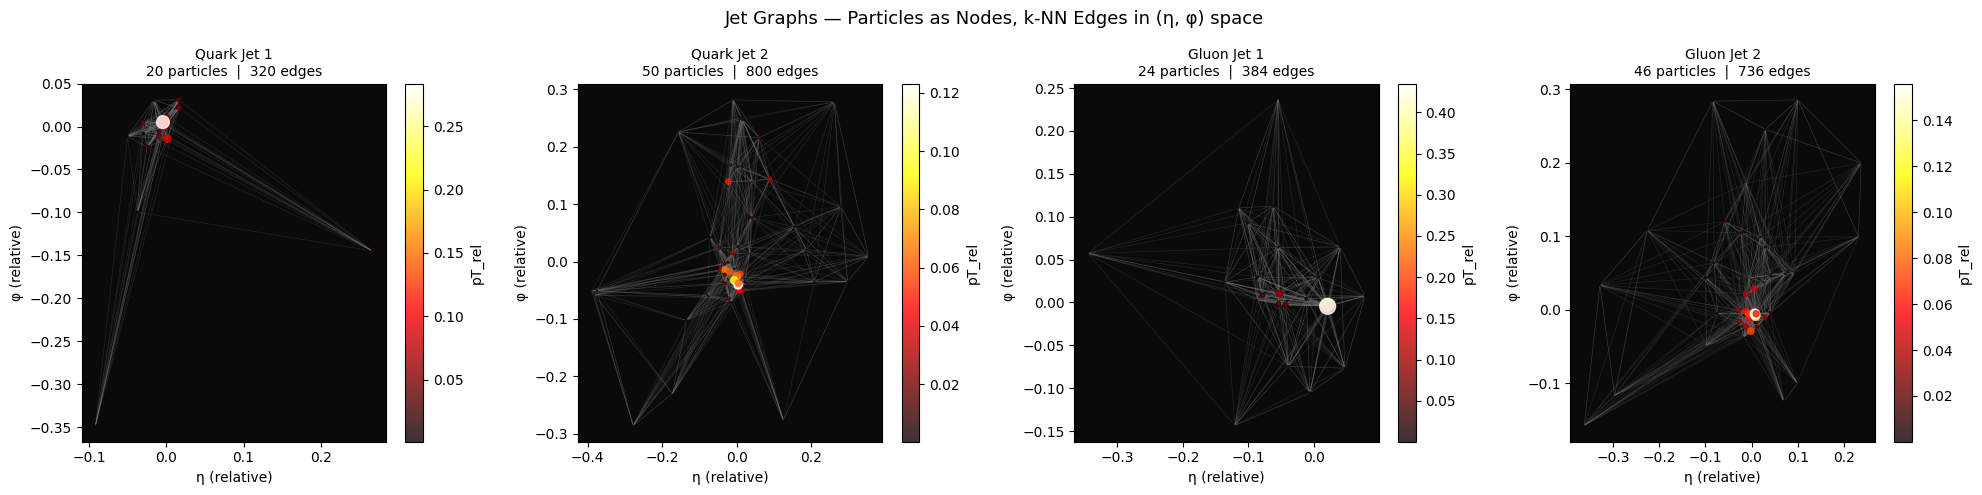

✔ Plot saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Pick 4 jets — 2 quarks and 2 gluons ───────────────────────────────────────
quark_graphs = [g for g in train_data if g.y.item() == 1][:2]
gluon_graphs = [g for g in train_data if g.y.item() == 0][:2]
samples      = quark_graphs + gluon_graphs
titles       = ['Quark Jet 1', 'Quark Jet 2', 'Gluon Jet 1', 'Gluon Jet 2']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Jet Graphs — Particles as Nodes, k-NN Edges in (η, φ) space',
             fontsize=13)

for ax, g, title in zip(axes, samples, titles):

    # Node positions: eta_rel and phi_rel are features 1 and 2
    eta = g.x[:, 1].numpy()
    phi = g.x[:, 2].numpy()
    pt  = g.x[:, 0].numpy()   # pt_rel — used for node size

    # Draw edges
    src, dst = g.edge_index.numpy()
    for s, d in zip(src, dst):
        ax.plot([eta[s], eta[d]],
                [phi[s], phi[d]],
                color='gray', alpha=0.2, linewidth=0.5, zorder=1)

    # Draw nodes — size proportional to pt_rel, color by pt_rel
    sc = ax.scatter(eta, phi,
                    s=pt * 300,          # node size
                    c=pt,                # node color
                    cmap='hot',
                    alpha=0.8,
                    zorder=2)

    ax.set_xlabel('η (relative)', fontsize=10)
    ax.set_ylabel('φ (relative)', fontsize=10)
    ax.set_title(f'{title}\n'
                 f'{g.x.shape[0]} particles  |  '
                 f'{g.edge_index.shape[1]} edges',
                 fontsize=10)
    ax.set_facecolor('#0a0a0a')
    plt.colorbar(sc, ax=ax, label='pT_rel')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/jet_gnn/results/jet_graphs.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✔ Plot saved to Drive')

In [ ]:
%%writefile /content/jet_gnn/models/particle_net.py
import torch
import torch.nn as nn
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool, global_max_pool

def mlp_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Linear(in_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU()
    )

def make_edge_mlp(in_ch, out_ch):
    return nn.Sequential(
        nn.Linear(2 * in_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU(),
        nn.Linear(out_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU()
    )

class ParticleNet(nn.Module):
    def __init__(self, in_channels=6, k=16,
                 edge_channels=(64, 128, 256),
                 fc_channels=256, num_classes=2, dropout=0.1):
        super().__init__()
        self.k = k
        ch = in_channels
        self.convs = nn.ModuleList()
        for out_ch in edge_channels:
            self.convs.append(
                DynamicEdgeConv(make_edge_mlp(ch, out_ch), k=k, aggr='max')
            )
            ch = out_ch

        self.classifier = nn.Sequential(
            nn.Linear(2 * edge_channels[-1], fc_channels),
            nn.BatchNorm1d(fc_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels, fc_channels // 2),
            nn.BatchNorm1d(fc_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels // 2, num_classes)
        )

    def forward(self, data):
        x, batch = data.x, data.batch
        for conv in self.convs:
            x = conv(x, batch)
        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=-1)
        return self.classifier(x)

Overwriting /content/jet_gnn/models/particle_net.py


In [ ]:
%%writefile /content/jet_gnn/models/__init__.py
from .particle_net import ParticleNet

Overwriting /content/jet_gnn/models/__init__.py


In [ ]:
print(open('/content/jet_gnn/models/particle_net.py').read())

import torch
import torch.nn as nn
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool, global_max_pool

def mlp_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Linear(in_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU()
    )

def make_edge_mlp(in_ch, out_ch):
    return nn.Sequential(
        nn.Linear(2 * in_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU(),
        nn.Linear(out_ch, out_ch),
        nn.BatchNorm1d(out_ch),
        nn.ReLU()
    )

class ParticleNet(nn.Module):
    def __init__(self, in_channels=6, k=16,
                 edge_channels=(64, 128, 256),
                 fc_channels=256, num_classes=2, dropout=0.1):
        super().__init__()
        self.k = k
        ch = in_channels
        self.convs = nn.ModuleList()
        for out_ch in edge_channels:
            self.convs.append(
                DynamicEdgeConv(make_edge_mlp(ch, out_ch), k=k, aggr='max')
            )
            ch = out_ch

        self.classi

In [ ]:
print(open('/content/jet_gnn/models/__init__.py').read())

from .particle_net import ParticleNet



In [ ]:
import sys

# Remove cached old version
for mod in list(sys.modules.keys()):
    if 'models' in mod or 'particle_net' in mod:
        del sys.modules[mod]

# Fresh import
sys.path.insert(0, '/content/jet_gnn')
from models.particle_net import ParticleNet

model = ParticleNet()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print('✔ ParticleNet loaded successfully')

Parameters: 337,922
✔ ParticleNet loaded successfully


In [ ]:
%%writefile /content/jet_gnn/trainer.py
import time
import json
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
from pathlib import Path
from models import ParticleNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Model builder ──────────────────────────────────────────────────────────────
def build_model(name):
    if name == 'particlenet':
        return ParticleNet(
            in_channels   = 6,
            k             = 16,
            edge_channels = (64, 128, 256),
            fc_channels   = 256,
            dropout       = 0.1
        )
    raise ValueError(f'Unknown model: {name}')

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ── LR schedule ───────────────────────────────────────────────────────────────
def lr_schedule(optimizer, epoch, warmup, total, base_lr):
    if epoch < warmup:
        lr = base_lr * (epoch + 1) / warmup
    else:
        progress = (epoch - warmup) / (total - warmup)
        lr = base_lr * 0.5 * (1.0 + np.cos(np.pi * progress))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr

# ── Single epoch ──────────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer, criterion, scaler, training):
    model.train(training)
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(DEVICE)

            with torch.amp.autocast(device_type='cuda',
                                     enabled=(DEVICE.type == 'cuda')):
                logits = model(batch)
                loss   = criterion(logits, batch.y.squeeze())

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * batch.num_graphs
            probs = torch.softmax(logits.detach(), dim=-1)[:, 1].cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(batch.y.squeeze().cpu().numpy())

    n   = len(all_labels)
    acc = ((np.array(all_preds) > 0.5).astype(int) == np.array(all_labels)).mean()
    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / n, acc, auc

# ── Main training function ─────────────────────────────────────────────────────
def train_model(
    model_name,
    train_data, val_data, test_data,
    ckpt_dir, log_dir,
    epochs        = 30,
    batch_size    = 128,
    lr            = 1e-3,
    patience      = 7,
    warmup_epochs = 3,
):
    ckpt_dir    = Path(ckpt_dir)
    log_dir     = Path(log_dir)
    ckpt_path   = ckpt_dir / f'{model_name}_best.pt'
    resume_path = ckpt_dir / f'{model_name}_resume.pt'
    log_path    = log_dir  / f'{model_name}_history.json'

    # ── DataLoaders ───────────────────────────────────────────────────────────
    train_loader = DataLoader(
        train_data, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader   = DataLoader(
        val_data, batch_size=batch_size * 2,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader  = DataLoader(
        test_data, batch_size=batch_size * 2,
        shuffle=False, num_workers=2, pin_memory=True
    )

    # ── Model, optimizer, loss ────────────────────────────────────────────────
    model     = build_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    start_epoch  = 0
    best_val_auc = 0.0
    patience_ctr = 0
    history      = []

    # ── Resume from checkpoint if exists ─────────────────────────────────────
    if resume_path.exists():
        print(f'[trainer] Resuming from {resume_path}')
        ckpt = torch.load(resume_path, map_location=DEVICE,weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        start_epoch  = ckpt['epoch']
        best_val_auc = ckpt['best_val_auc']
        patience_ctr = ckpt['patience_ctr']
        history      = ckpt['history']
        print(f'[trainer] Resumed at epoch {start_epoch + 1}, '
              f'best AUC so far = {best_val_auc:.4f}')
    else:
        print(f'[trainer] Starting fresh')
        print(f'[trainer] Parameters : {count_params(model):,}')

    print(f'[trainer] Device     : {DEVICE}')
    print(f'[trainer] Epochs     : {start_epoch + 1} → {epochs}')
    print(f'[trainer] Batch size : {batch_size}')
    print('=' * 65)

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, epochs):
        t0     = time.time()
        lr_now = lr_schedule(optimizer, epoch, warmup_epochs, epochs, lr)

        tr_loss, tr_acc, tr_auc = run_epoch(
            model, train_loader, optimizer, criterion, scaler, training=True)
        vl_loss, vl_acc, vl_auc = run_epoch(
            model, val_loader, optimizer, criterion, scaler, training=False)

        dt = time.time() - t0
        print(f'Ep {epoch+1:>3}/{epochs}  '
              f'lr={lr_now:.2e}  '
              f'train[loss={tr_loss:.4f} acc={tr_acc:.4f} auc={tr_auc:.4f}]  '
              f'val[loss={vl_loss:.4f} acc={vl_acc:.4f} auc={vl_auc:.4f}]  '
              f'{dt:.0f}s')

        history.append(dict(
            epoch=epoch + 1, lr=lr_now,
            train_loss=tr_loss, train_acc=tr_acc, train_auc=tr_auc,
            val_loss=vl_loss,   val_acc=vl_acc,   val_auc=vl_auc,
        ))

        # ── Save best model ───────────────────────────────────────────────────
        if vl_auc > best_val_auc:
            best_val_auc = vl_auc
            patience_ctr = 0
            torch.save({
                'epoch':       epoch + 1,
                'model_state': model.state_dict(),
                'val_auc':     vl_auc,
            }, ckpt_path)
            print(f'  ✔ Best model saved  (val AUC={best_val_auc:.4f})')
        else:
            patience_ctr += 1

        # ── Save resume checkpoint every epoch ────────────────────────────────
        torch.save({
            'epoch':            epoch + 1,
            'model_state':      model.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'scaler_state':     scaler.state_dict(),
            'best_val_auc':     best_val_auc,
            'patience_ctr':     patience_ctr,
            'history':          history,
        }, resume_path)

        # ── Save log every epoch ──────────────────────────────────────────────
        with open(log_path, 'w') as f:
            json.dump({'history': history}, f, indent=2)

        # ── Early stopping ────────────────────────────────────────────────────
        if patience_ctr >= patience:
            print(f'\n  Early stopping — no improvement for {patience} epochs.')
            break

    # ── Final test evaluation ─────────────────────────────────────────────────
    print('\n' + '-' * 65)
    print('Loading best checkpoint for test evaluation ...')
    best_ckpt = torch.load(ckpt_path, map_location=DEVICE,weights_only=False)
    model.load_state_dict(best_ckpt['model_state'])

    te_loss, te_acc, te_auc = run_epoch(
        model, test_loader, optimizer, criterion, scaler, training=False)

    print(f'\nTEST  loss={te_loss:.4f}  acc={te_acc:.4f}  AUC={te_auc:.4f}')
    print('-' * 65)

    # ── Save final log ────────────────────────────────────────────────────────
    with open(log_path, 'w') as f:
        json.dump({
            'history':   history,
            'test_loss': te_loss,
            'test_acc':  te_acc,
            'test_auc':  te_auc,
        }, f, indent=2)

    print(f'[trainer] Log saved → {log_path}')
    return history, te_auc

Overwriting /content/jet_gnn/trainer.py


In [ ]:
import os
for f in sorted(os.walk('/content/jet_gnn')):
    print(f)

('/content/jet_gnn', ['models', '__pycache__'], ['data_loader.py', 'trainer.py'])
('/content/jet_gnn/__pycache__', [], ['data_loader.cpython-312.pyc'])
('/content/jet_gnn/models', ['.ipynb_checkpoints', '__pycache__'], ['__init__.py', 'particle_net.py'])
('/content/jet_gnn/models/.ipynb_checkpoints', [], [])
('/content/jet_gnn/models/__pycache__', [], ['__init__.cpython-312.pyc', 'particle_net.cpython-312.pyc'])


In [ ]:
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'trainer', 'particle_net']):
        del sys.modules[mod]

sys.path.insert(0, '/content/jet_gnn')

import torch
from torch_geometric.data import Data, Batch
from models import ParticleNet

# Quick forward pass test
def fake_batch(n_jets=4, n_particles=50):
    graphs = []
    for _ in range(n_jets):
        x          = torch.randn(n_particles, 6)
        src        = torch.randint(0, n_particles, (n_particles * 16,))
        dst        = torch.randint(0, n_particles, (n_particles * 16,))
        edge_index = torch.stack([src, dst])
        edge_attr  = torch.randn(n_particles * 16, 4)
        y          = torch.randint(0, 2, (1,))
        graphs.append(Data(x=x, edge_index=edge_index,
                           edge_attr=edge_attr, y=y))
    return Batch.from_data_list(graphs)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch  = fake_batch().to(device)
model  = ParticleNet().to(device)
out    = model(batch)

print(f'Output shape : {out.shape}  (expected [4, 2])')
print(f'Parameters   : {sum(p.numel() for p in model.parameters()):,}')
print('✔ ParticleNet working')

Output shape : torch.Size([4, 2])  (expected [4, 2])
Parameters   : 336,642
✔ ParticleNet working


In [ ]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


In [ ]:
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'trainer', 'particle_net']):
        del sys.modules[mod]

from pathlib import Path
from trainer import train_model

DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')

history, test_auc = train_model(
    model_name    = 'particlenet',
    train_data    = train_data,
    val_data      = val_data,
    test_data     = test_data,
    ckpt_dir      = DRIVE_ROOT / 'checkpoints',
    log_dir       = DRIVE_ROOT / 'logs',
    epochs        = 30,
    batch_size    = 128,
    lr            = 1e-3,
    patience      = 7,
    warmup_epochs = 3,
)

[trainer] Starting fresh
[trainer] Parameters : 336,642
[trainer] Device     : cuda
[trainer] Epochs     : 1 → 30
[trainer] Batch size : 128
Ep   1/30  lr=3.33e-04  train[loss=0.4928 acc=0.7855 auc=0.8597]  val[loss=0.4816 acc=0.7899 auc=0.8703]  32s
  ✔ Best model saved  (val AUC=0.8703)
Ep   2/30  lr=6.67e-04  train[loss=0.4783 acc=0.7951 auc=0.8708]  val[loss=0.4817 acc=0.7933 auc=0.8742]  30s
  ✔ Best model saved  (val AUC=0.8742)
Ep   3/30  lr=1.00e-03  train[loss=0.4725 acc=0.7990 auc=0.8752]  val[loss=0.4910 acc=0.7857 auc=0.8735]  30s
Ep   4/30  lr=1.00e-03  train[loss=0.4649 acc=0.8049 auc=0.8804]  val[loss=0.4661 acc=0.8035 auc=0.8829]  29s
  ✔ Best model saved  (val AUC=0.8829)
Ep   5/30  lr=9.97e-04  train[loss=0.4580 acc=0.8104 auc=0.8849]  val[loss=0.4917 acc=0.7816 auc=0.8746]  29s
Ep   6/30  lr=9.87e-04  train[loss=0.4535 acc=0.8130 auc=0.8880]  val[loss=0.4732 acc=0.8035 auc=0.8829]  29s
  ✔ Best model saved  (val AUC=0.8829)
Ep   7/30  lr=9.70e-04  train[loss=0.4485 a

UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy.core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn mor

In [ ]:
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'trainer', 'particle_net']):
        del sys.modules[mod]

sys.path.insert(0, '/content/jet_gnn')

import torch
import numpy as np
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
from pathlib import Path
from models import ParticleNet
from trainer import run_epoch, DEVICE

DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')
ckpt_path  = DRIVE_ROOT / 'checkpoints' / 'particlenet_best.pt'

# Load best checkpoint
model    = ParticleNet().to(DEVICE)
ckpt     = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

# Run test
import torch.nn as nn
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters())
scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

test_loader = DataLoader(test_data, batch_size=256,
                         shuffle=False, num_workers=2)

te_loss, te_acc, te_auc = run_epoch(
    model, test_loader, optimizer, criterion, scaler, training=False)

print('=' * 50)
print(f'TEST RESULTS — ParticleNet')
print('=' * 50)
print(f'Loss : {te_loss:.4f}')
print(f'Acc  : {te_acc:.4f}')
print(f'AUC  : {te_auc:.4f}')
print('=' * 50)


TEST RESULTS — ParticleNet
Loss : 0.4559
Acc  : 0.8113
AUC  : 0.8877


In [ ]:
import sys
sys.path.insert(0, '/content/jet_gnn')

import torch
import numpy as np
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
from pathlib import Path
from models import ParticleNet
from trainer import DEVICE
from data_loader import jet_to_graph

# ── Load Herwig jets ──────────────────────────────────────────────────────────
print('Loading Herwig jets ...')
X_h, y_h = ef.qg_jets.load(
    num_data  = 20_000,
    pad       = True,
    generator = 'herwig',
    with_bc   = False,
)
print(f'Herwig jets : {X_h.shape}')
print(f'Quarks      : {(y_h==1).sum():,}')
print(f'Gluons      : {(y_h==0).sum():,}')

# ── Build graphs ──────────────────────────────────────────────────────────────
print('Building graphs ...')
herwig_graphs = []
for i, (particles, label) in enumerate(zip(X_h, y_h)):
    g = jet_to_graph(particles)
    if g is not None:
        g.y = torch.tensor([int(label)], dtype=torch.long)
        herwig_graphs.append(g)

print(f'Valid graphs : {len(herwig_graphs):,}')

# ── Load trained ParticleNet ──────────────────────────────────────────────────
DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')
ckpt_path  = DRIVE_ROOT / 'checkpoints' / 'particlenet_best.pt'

model  = ParticleNet().to(DEVICE)
ckpt   = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

# ── Run inference ─────────────────────────────────────────────────────────────
loader = DataLoader(herwig_graphs, batch_size=256,
                    shuffle=False, num_workers=2)

all_probs, all_labels = [], []
with torch.no_grad():
    for batch in loader:
        batch = batch.to(DEVICE)
        probs = torch.softmax(model(batch), dim=-1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(batch.y.squeeze().cpu().numpy())

auc = roc_auc_score(all_labels, all_probs)
acc = ((np.array(all_probs) > 0.5).astype(int) == np.array(all_labels)).mean()

print()
print('=' * 50)
print('Cross-generator test — Pythia → Herwig')
print('=' * 50)
print(f'Pythia test AUC  : 0.8877  (same generator)')
print(f'Herwig test AUC  : {auc:.4f}  (unseen generator)')
print(f'Herwig test Acc  : {acc:.4f}')
print('=' * 50)

Loading Herwig jets ...
Herwig jets : (20000, 136, 4)
Quarks      : 10,015
Gluons      : 9,985
Building graphs ...
Valid graphs : 20,000

Cross-generator test — Pythia → Herwig
Pythia test AUC  : 0.8877  (same generator)
Herwig test AUC  : 0.7992  (unseen generator)
Herwig test Acc  : 0.7109


In [ ]:
import os
os.chdir('/content')
print(os.getcwd())

/content


In [ ]:
%%writefile /content/jet_gnn/src/models/jet_gat.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

class JetGAT(nn.Module):
    def __init__(self, in_channels=6, hidden_dim=64, heads=4,
                 num_layers=3, fc_channels=256, num_classes=2,
                 dropout=0.1, edge_dim=4):
        super().__init__()
        self.dropout = dropout

        self.input_proj = nn.Linear(in_channels, hidden_dim * heads)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        ch = hidden_dim * heads
        for i in range(num_layers):
            is_last = (i == num_layers - 1)
            self.convs.append(GATv2Conv(
                in_channels   = ch,
                out_channels  = hidden_dim,
                heads         = 1 if is_last else heads,
                concat        = not is_last,
                dropout       = dropout,
                edge_dim      = edge_dim,
                share_weights = False
            ))
            out_ch = hidden_dim if is_last else hidden_dim * heads
            self.norms.append(nn.LayerNorm(out_ch))
            ch = out_ch

        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, fc_channels),
            nn.LayerNorm(fc_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels, fc_channels // 2),
            nn.LayerNorm(fc_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels // 2, num_classes)
        )

    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch

        x = F.gelu(self.input_proj(x))

        for conv, norm in zip(self.convs, self.norms):
            x_new = conv(x, edge_index, edge_attr=edge_attr)
            x_new = norm(x_new)
            x_new = F.gelu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = x + x_new if x.shape == x_new.shape else x_new

        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=-1)
        return self.classifier(x)

Writing /content/jet_gnn/src/models/jet_gat.py


FileNotFoundError: [Errno 2] No such file or directory: '/content/jet_gnn/src/models/jet_gat.py'

In [ ]:
import os

if os.path.exists('/content/jet_gnn/src/models'):
    print('✔ Directory exists')
    print('\nFiles inside:')
    for f in os.listdir('/content/jet_gnn/src/models'):
        print(f'  {f}')
else:
    print('✘ Directory does not exist')

✘ Directory does not exist


In [ ]:
import os
for root, dirs, files in os.walk('/content/jet_gnn'):
    for f in files:
        print(os.path.join(root, f))
    for d in dirs:
        print(os.path.join(root, d) + '/')

In [ ]:
# Step 1 - Remount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Step 2 - Check what's on Drive
import os
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')
print('Files on Drive:')
for root, dirs, files in os.walk(DRIVE_ROOT):
    for f in files:
        print(os.path.join(root, f))
    for d in dirs:
        print(os.path.join(root, d) + '/')

Files on Drive:
/content/drive/MyDrive/jet_gnn/src/
/content/drive/MyDrive/jet_gnn/checkpoints/
/content/drive/MyDrive/jet_gnn/logs/
/content/drive/MyDrive/jet_gnn/results/
/content/drive/MyDrive/jet_gnn/energyflow_cache/
/content/drive/MyDrive/jet_gnn/graphs_cache/
/content/drive/MyDrive/jet_gnn/src/data_loader.py
/content/drive/MyDrive/jet_gnn/src/trainer.py
/content/drive/MyDrive/jet_gnn/src/models/
/content/drive/MyDrive/jet_gnn/src/__pycache__/
/content/drive/MyDrive/jet_gnn/src/models/__init__.py
/content/drive/MyDrive/jet_gnn/src/models/particle_net.py
/content/drive/MyDrive/jet_gnn/src/models/.ipynb_checkpoints/
/content/drive/MyDrive/jet_gnn/src/models/__pycache__/
/content/drive/MyDrive/jet_gnn/src/models/__pycache__/__init__.cpython-312.pyc
/content/drive/MyDrive/jet_gnn/src/models/__pycache__/particle_net.cpython-312.pyc
/content/drive/MyDrive/jet_gnn/src/__pycache__/data_loader.cpython-312.pyc
/content/drive/MyDrive/jet_gnn/src/__pycache__/trainer.cpython-312.pyc
/content/

In [ ]:
# Step 1 - Recreate symlink
import os, sys

if os.path.exists('/content/jet_gnn'):
    os.unlink('/content/jet_gnn')

os.symlink('/content/drive/MyDrive/jet_gnn/src', '/content/jet_gnn')
sys.path.insert(0, '/content/jet_gnn')

os.chdir('/content/jet_gnn')
print('✔ Symlink restored')
print('Files:', os.listdir('/content/jet_gnn'))

✔ Symlink restored
Files: ['models', '__pycache__', 'data_loader.py', 'trainer.py']


In [ ]:
# Step 2 - Restore EnergyFlow cache
import shutil
from pathlib import Path

CACHE_DIR   = Path('/content/drive/MyDrive/jet_gnn/energyflow_cache')
LOCAL_CACHE = Path('/root/.energyflow')

if LOCAL_CACHE.exists():
    shutil.rmtree(LOCAL_CACHE)
shutil.copytree(str(CACHE_DIR), str(LOCAL_CACHE))
print('✔ EnergyFlow cache restored')

✔ EnergyFlow cache restored


In [ ]:
# Step 3 - Write jet_gat.py to correct path
%%writefile /content/jet_gnn/models/jet_gat.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool, global_max_pool

class JetGAT(nn.Module):
    def __init__(self, in_channels=6, hidden_dim=64, heads=4,
                 num_layers=3, fc_channels=256, num_classes=2,
                 dropout=0.1, edge_dim=4):
        super().__init__()
        self.dropout = dropout

        self.input_proj = nn.Linear(in_channels, hidden_dim * heads)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        ch = hidden_dim * heads
        for i in range(num_layers):
            is_last = (i == num_layers - 1)
            self.convs.append(GATv2Conv(
                in_channels   = ch,
                out_channels  = hidden_dim,
                heads         = 1 if is_last else heads,
                concat        = not is_last,
                dropout       = dropout,
                edge_dim      = edge_dim,
                share_weights = False
            ))
            out_ch = hidden_dim if is_last else hidden_dim * heads
            self.norms.append(nn.LayerNorm(out_ch))
            ch = out_ch

        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, fc_channels),
            nn.LayerNorm(fc_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels, fc_channels // 2),
            nn.LayerNorm(fc_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fc_channels // 2, num_classes)
        )

    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch

        x = F.gelu(self.input_proj(x))

        for conv, norm in zip(self.convs, self.norms):
            x_new = conv(x, edge_index, edge_attr=edge_attr)
            x_new = norm(x_new)
            x_new = F.gelu(x_new)
            x_new = F.dropout(x_new, p=self.dropout, training=self.training)
            x = x + x_new if x.shape == x_new.shape else x_new

        x = torch.cat([global_mean_pool(x, batch),
                        global_max_pool(x, batch)], dim=-1)
        return self.classifier(x)

Writing /content/jet_gnn/models/jet_gat.py


In [ ]:
# Step 4 - Update __init__.py
%%writefile /content/jet_gnn/models/__init__.py
from .particle_net import ParticleNet
from .jet_gat import JetGAT

Overwriting /content/jet_gnn/models/__init__.py


In [ ]:
# Step 6 - Smoke test JetGAT
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'jet_gat']):
        del sys.modules[mod]

sys.path.insert(0, '/content/jet_gnn')

import torch
from torch_geometric.data import Data, Batch
from models import JetGAT

def fake_batch(n_jets=4, n_particles=50):
    graphs = []
    for _ in range(n_jets):
        x          = torch.randn(n_particles, 6)
        src        = torch.randint(0, n_particles, (n_particles * 16,))
        dst        = torch.randint(0, n_particles, (n_particles * 16,))
        edge_index = torch.stack([src, dst])
        edge_attr  = torch.randn(n_particles * 16, 4)
        y          = torch.randint(0, 2, (1,))
        graphs.append(Data(x=x, edge_index=edge_index,
                           edge_attr=edge_attr, y=y))
    return Batch.from_data_list(graphs)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch  = fake_batch().to(device)
model  = JetGAT().to(device)
out    = model(batch)

print(f'Device       : {device}')
print(f'Output shape : {out.shape}  (expected [4, 2])')
print(f'Parameters   : {sum(p.numel() for p in model.parameters()):,}')
print('✔ JetGAT working')

Device       : cuda
Output shape : torch.Size([4, 2])  (expected [4, 2])
Parameters   : 369,410
✔ JetGAT working


In [ ]:
%%writefile /content/jet_gnn/trainer.py
import time
import json
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
from pathlib import Path
from models import ParticleNet, JetGAT

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(name):
    if name == 'particlenet':
        return ParticleNet(
            in_channels   = 6,
            k             = 16,
            edge_channels = (64, 128, 256),
            fc_channels   = 256,
            dropout       = 0.1
        )
    elif name == 'jetgat':
        return JetGAT(
            in_channels  = 6,
            hidden_dim   = 64,
            heads        = 4,
            num_layers   = 3,
            fc_channels  = 256,
            dropout      = 0.1,
            edge_dim     = 4
        )
    raise ValueError(f'Unknown model: {name}')

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def lr_schedule(optimizer, epoch, warmup, total, base_lr):
    if epoch < warmup:
        lr = base_lr * (epoch + 1) / warmup
    else:
        progress = (epoch - warmup) / (total - warmup)
        lr = base_lr * 0.5 * (1.0 + np.cos(np.pi * progress))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr

def run_epoch(model, loader, optimizer, criterion, scaler, training):
    model.train(training)
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(DEVICE)
            with torch.amp.autocast(device_type='cuda',
                                     enabled=(DEVICE.type == 'cuda')):
                logits = model(batch)
                loss   = criterion(logits, batch.y.squeeze())

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * batch.num_graphs
            probs = torch.softmax(logits.detach(), dim=-1)[:, 1].cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(batch.y.squeeze().cpu().numpy())

    n   = len(all_labels)
    acc = ((np.array(all_preds) > 0.5).astype(int) == np.array(all_labels)).mean()
    auc = roc_auc_score(all_labels, all_preds)
    return total_loss / n, acc, auc

def train_model(
    model_name,
    train_data, val_data, test_data,
    ckpt_dir, log_dir,
    epochs        = 30,
    batch_size    = 128,
    lr            = 1e-3,
    patience      = 7,
    warmup_epochs = 3,
):
    ckpt_dir    = Path(ckpt_dir)
    log_dir     = Path(log_dir)
    ckpt_path   = ckpt_dir / f'{model_name}_best.pt'
    resume_path = ckpt_dir / f'{model_name}_resume.pt'
    log_path    = log_dir  / f'{model_name}_history.json'

    train_loader = DataLoader(
        train_data, batch_size=batch_size,
        shuffle=True, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_data, batch_size=batch_size * 2,
        shuffle=False, num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_data, batch_size=batch_size * 2,
        shuffle=False, num_workers=2, pin_memory=True
    )

    model     = build_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler    = torch.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

    start_epoch  = 0
    best_val_auc = 0.0
    patience_ctr = 0
    history      = []

    if resume_path.exists():
        print(f'[trainer] Resuming from {resume_path}')
        ckpt = torch.load(resume_path, map_location=DEVICE,
                          weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        start_epoch  = ckpt['epoch']
        best_val_auc = ckpt['best_val_auc']
        patience_ctr = ckpt['patience_ctr']
        history      = ckpt['history']
        print(f'[trainer] Resumed at epoch {start_epoch + 1}  '
              f'best AUC so far = {best_val_auc:.4f}')
    else:
        print(f'[trainer] Starting fresh')
        print(f'[trainer] Parameters : {count_params(model):,}')

    print(f'[trainer] Device     : {DEVICE}')
    print(f'[trainer] Epochs     : {start_epoch + 1} → {epochs}')
    print(f'[trainer] Batch size : {batch_size}')
    print('=' * 65)

    for epoch in range(start_epoch, epochs):
        t0     = time.time()
        lr_now = lr_schedule(optimizer, epoch, warmup_epochs, epochs, lr)

        tr_loss, tr_acc, tr_auc = run_epoch(
            model, train_loader, optimizer, criterion, scaler, training=True)
        vl_loss, vl_acc, vl_auc = run_epoch(
            model, val_loader, optimizer, criterion, scaler, training=False)

        dt = time.time() - t0
        print(f'Ep {epoch+1:>3}/{epochs}  '
              f'lr={lr_now:.2e}  '
              f'train[loss={tr_loss:.4f} acc={tr_acc:.4f} auc={tr_auc:.4f}]  '
              f'val[loss={vl_loss:.4f} acc={vl_acc:.4f} auc={vl_auc:.4f}]  '
              f'{dt:.0f}s')

        history.append(dict(
            epoch=epoch + 1,     lr=lr_now,
            train_loss=tr_loss,  train_acc=tr_acc,  train_auc=tr_auc,
            val_loss=vl_loss,    val_acc=vl_acc,    val_auc=vl_auc,
        ))

        if vl_auc > best_val_auc:
            best_val_auc = vl_auc
            patience_ctr = 0
            torch.save({
                'epoch':       epoch + 1,
                'model_state': model.state_dict(),
                'val_auc':     vl_auc,
            }, ckpt_path)
            print(f'  ✔ Best model saved  (val AUC={best_val_auc:.4f})')
        else:
            patience_ctr += 1

        torch.save({
            'epoch':           epoch + 1,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scaler_state':    scaler.state_dict(),
            'best_val_auc':    best_val_auc,
            'patience_ctr':    patience_ctr,
            'history':         history,
        }, resume_path)

        with open(log_path, 'w') as f:
            json.dump({'history': history}, f, indent=2)

        if patience_ctr >= patience:
            print(f'\n  Early stopping — no improvement for {patience} epochs.')
            break

    print('\n' + '-' * 65)
    print('Loading best checkpoint for test evaluation ...')
    best_ckpt = torch.load(ckpt_path, map_location=DEVICE,
                           weights_only=False)
    model.load_state_dict(best_ckpt['model_state'])

    te_loss, te_acc, te_auc = run_epoch(
        model, test_loader, optimizer, criterion, scaler, training=False)

    print(f'\nTEST  loss={te_loss:.4f}  acc={te_acc:.4f}  AUC={te_auc:.4f}')
    print('-' * 65)

    with open(log_path, 'w') as f:
        json.dump({
            'history':   history,
            'test_loss': te_loss,
            'test_acc':  te_acc,
            'test_auc':  te_auc,
        }, f, indent=2)

    print(f'[trainer] Log saved → {log_path}')
    return history, te_auc

Overwriting /content/jet_gnn/trainer.py


In [ ]:
# Check both models are in build_model
content = open('/content/jet_gnn/trainer.py').read()
print('particlenet' in content)   # must be True
print('jetgat'      in content)   # must be True
print('trainer.py updated')

True
True
trainer.py updated


In [ ]:
import sys
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'trainer', 'data_loader']):
        del sys.modules[mod]

sys.path.insert(0, '/content/jet_gnn')

from pathlib import Path
from data_loader import load_dataset
from trainer import train_model

DRIVE_ROOT = Path('/content/drive/MyDrive/jet_gnn')

# Load from cache — should be instant
train_data, val_data, test_data = load_dataset(
    n_per_class      = 50_000,
    graphs_cache_dir = DRIVE_ROOT / 'graphs_cache',
    ef_cache_dir     = DRIVE_ROOT / 'energyflow_cache',
)

# Train JetGAT
history_gat, test_auc_gat = train_model(
    model_name    = 'jetgat',
    train_data    = train_data,
    val_data      = val_data,
    test_data     = test_data,
    ckpt_dir      = DRIVE_ROOT / 'checkpoints',
    log_dir       = DRIVE_ROOT / 'logs',
    epochs        = 30,
    batch_size    = 256,
    lr            = 1e-3,
    patience      = 7,
    warmup_epochs = 3,
)

print(f'\nJetGAT      AUC : {test_auc_gat:.4f}')
print(f'ParticleNet AUC : 0.8877')
print(f'Difference      : {test_auc_gat - 0.8877:+.4f}')

[data_loader] Loading from cache: /content/drive/MyDrive/jet_gnn/graphs_cache/balanced_n50000_s42.pkl
[data_loader] train=70,000  val=15,000  test=15,000
[trainer] Starting fresh
[trainer] Parameters : 369,410
[trainer] Device     : cuda
[trainer] Epochs     : 1 → 30
[trainer] Batch size : 256
Ep   1/30  lr=3.33e-04  train[loss=0.5276 acc=0.7544 auc=0.8300]  val[loss=0.4928 acc=0.7867 auc=0.8623]  30s
  ✔ Best model saved  (val AUC=0.8623)
Ep   2/30  lr=6.67e-04  train[loss=0.5057 acc=0.7762 auc=0.8493]  val[loss=0.4902 acc=0.7935 auc=0.8686]  30s
  ✔ Best model saved  (val AUC=0.8686)
Ep   3/30  lr=1.00e-03  train[loss=0.4902 acc=0.7881 auc=0.8616]  val[loss=0.4836 acc=0.7929 auc=0.8714]  31s
  ✔ Best model saved  (val AUC=0.8714)
Ep   4/30  lr=1.00e-03  train[loss=0.4820 acc=0.7937 auc=0.8680]  val[loss=0.5479 acc=0.7422 auc=0.8754]  30s
  ✔ Best model saved  (val AUC=0.8754)
Ep   5/30  lr=9.97e-04  train[loss=0.4731 acc=0.7993 auc=0.8745]  val[loss=0.4646 acc=0.8049 auc=0.8805]  31s

**EVALUATION**

In [ ]:
# ── CELL 1: Setup and imports ─────────────────────────────────────────────────
import sys, json
import os

# Restore symlink if needed
if not os.path.exists('/content/jet_gnn'):
    os.symlink('/content/drive/MyDrive/jet_gnn/src', '/content/jet_gnn')

sys.path.insert(0, '/content/jet_gnn')

# Clear module cache
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['models', 'trainer', 'data_loader']):
        del sys.modules[mod]

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (roc_curve, roc_auc_score,
                              confusion_matrix, classification_report)
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Batch
from models import ParticleNet, JetGAT
from trainer import DEVICE, build_model
from data_loader import load_dataset, jet_to_graph
import energyflow as ef

DRIVE_ROOT  = Path('/content/drive/MyDrive/jet_gnn')
CKPT_DIR    = DRIVE_ROOT / 'checkpoints'
LOG_DIR     = DRIVE_ROOT / 'logs'
RESULTS_DIR = DRIVE_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

MODEL_CFGS = {
    'particlenet': {
        'color': '#E63946',
        'label': 'ParticleNet (DynamicEdgeConv)',
        'test_auc': 0.8877,
        'test_acc': 0.8113,
    },
    'jetgat': {
        'color': '#457B9D',
        'label': 'JetGAT (GATv2)',
        'test_auc': 0.8953,
        'test_acc': 0.8197,
    },
}

print('✔ Setup complete')
print(f'  Device     : {DEVICE}')
print(f'  Results dir: {RESULTS_DIR}')

✔ Setup complete
  Device     : cuda
  Results dir: /content/drive/MyDrive/jet_gnn/results


In [ ]:
# ── CELL 2: Load dataset from cache ──────────────────────────────────────────
train_data, val_data, test_data = load_dataset(
    n_per_class      = 50_000,
    graphs_cache_dir = DRIVE_ROOT / 'graphs_cache',
    ef_cache_dir     = DRIVE_ROOT / 'energyflow_cache',
)
print(f'✔ Dataset loaded: test={len(test_data):,} jets')

[data_loader] Loading from cache: /content/drive/MyDrive/jet_gnn/graphs_cache/balanced_n50000_s42.pkl
[data_loader] train=70,000  val=15,000  test=15,000
✔ Dataset loaded: test=15,000 jets


In [ ]:
# ── CELL 3: Get predictions from both models ──────────────────────────────────
@torch.no_grad()
def get_predictions(model_name, data, batch_size=512):
    model = build_model(model_name).to(DEVICE)
    ckpt  = torch.load(CKPT_DIR / f'{model_name}_best.pt',
                       map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    loader = DataLoader(data, batch_size=batch_size,
                        shuffle=False, num_workers=2)
    probs, labels = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        p     = torch.softmax(model(batch), dim=-1)[:, 1].cpu().numpy()
        probs.extend(p)
        labels.extend(batch.y.squeeze().cpu().numpy())

    return np.array(probs), np.array(labels)

results = {}
for name in MODEL_CFGS:
    print(f'Running inference: {name} ...')
    probs, labels    = get_predictions(name, test_data)
    fpr, tpr, thresh = roc_curve(labels, probs)
    auc              = roc_auc_score(labels, probs)
    acc              = ((probs > 0.5).astype(int) == labels).mean()
    preds            = (probs > 0.5).astype(int)

    results[name] = dict(
        fpr=fpr, tpr=tpr, thresh=thresh,
        auc=auc, acc=acc,
        probs=probs, labels=labels, preds=preds
    )
    print(f'  AUC={auc:.4f}  Acc={acc:.4f}')

print('\n✔ Inference complete')

Running inference: particlenet ...
  AUC=0.8878  Acc=0.8114
Running inference: jetgat ...
  AUC=0.8953  Acc=0.8196

✔ Inference complete


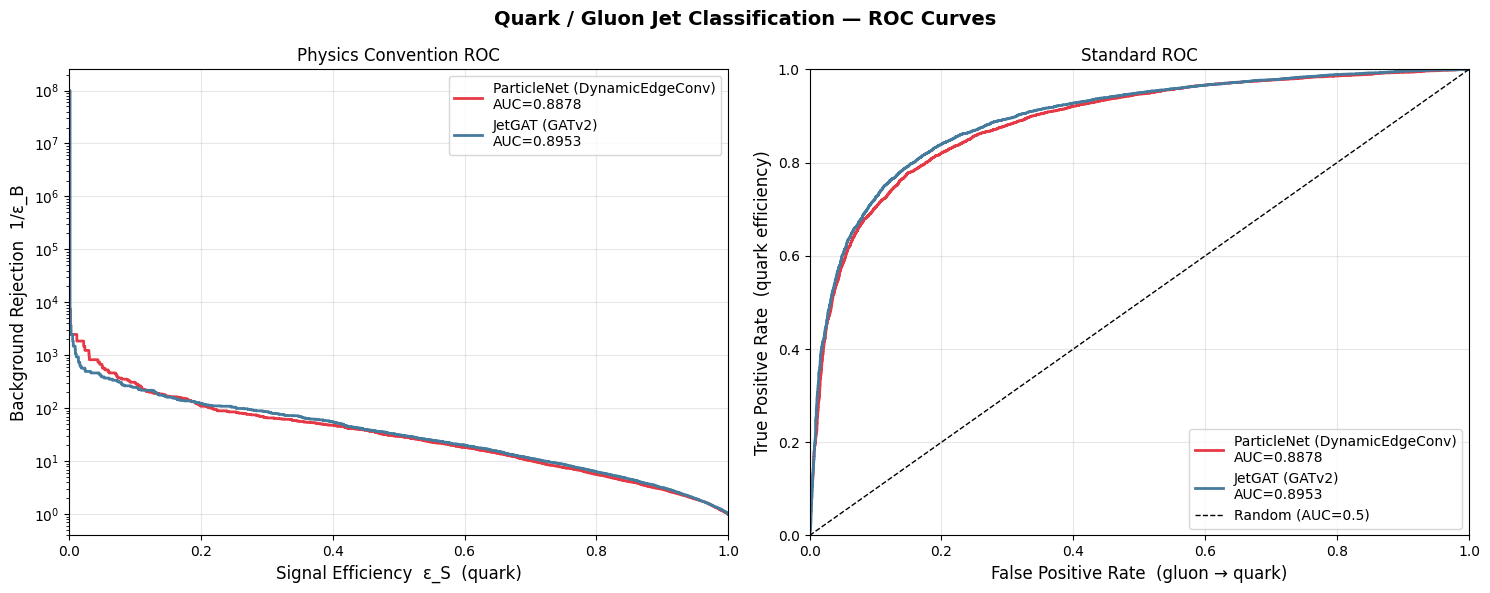

✔ Saved → /content/drive/MyDrive/jet_gnn/results/roc_curves.png


In [ ]:
# ── CELL 4: ROC curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Quark / Gluon Jet Classification — ROC Curves',
             fontsize=14, fontweight='bold')

# Physics convention: background rejection vs signal efficiency
ax = axes[0]
for name, cfg in MODEL_CFGS.items():
    r = results[name]
    ax.plot(r['tpr'], 1.0 / (r['fpr'] + 1e-8),
            color=cfg['color'], linewidth=2,
            label=f"{cfg['label']}\nAUC={r['auc']:.4f}")

ax.set_xlabel('Signal Efficiency  ε_S  (quark)', fontsize=12)
ax.set_ylabel('Background Rejection  1/ε_B', fontsize=12)
ax.set_title('Physics Convention ROC', fontsize=12)
ax.set_yscale('log')
ax.set_xlim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Standard ROC
ax = axes[1]
for name, cfg in MODEL_CFGS.items():
    r = results[name]
    ax.plot(r['fpr'], r['tpr'],
            color=cfg['color'], linewidth=2,
            label=f"{cfg['label']}\nAUC={r['auc']:.4f}")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate  (gluon → quark)', fontsize=12)
ax.set_ylabel('True Positive Rate  (quark efficiency)', fontsize=12)
ax.set_title('Standard ROC', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/roc_curves.png')

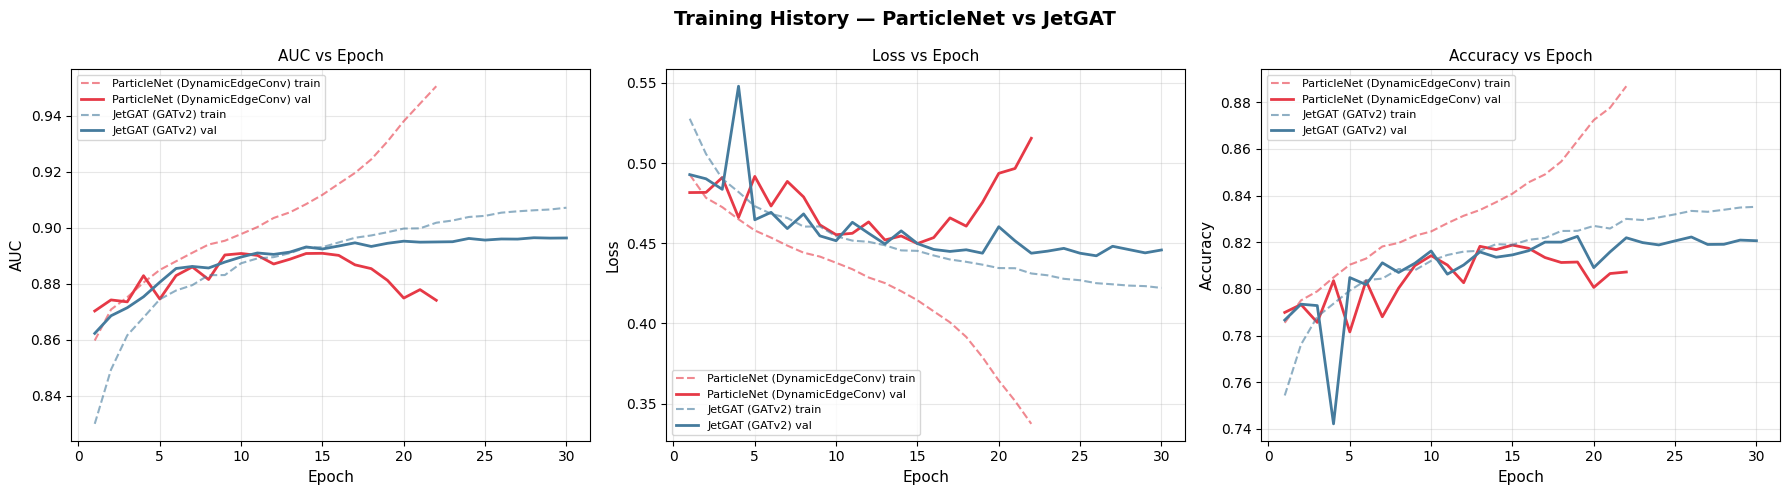

✔ Saved → /content/drive/MyDrive/jet_gnn/results/training_curves.png


In [ ]:
# ── CELL 5: Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — ParticleNet vs JetGAT',
             fontsize=14, fontweight='bold')

metrics = [
    ('val_auc',  'train_auc',  'AUC'),
    ('val_loss', 'train_loss', 'Loss'),
    ('val_acc',  'train_acc',  'Accuracy'),
]

for ax, (val_key, train_key, ylabel) in zip(axes, metrics):
    for name, cfg in MODEL_CFGS.items():
        log_path = LOG_DIR / f'{name}_history.json'
        if not log_path.exists():
            continue
        hist = json.load(open(log_path))['history']
        epochs     = [h['epoch']     for h in hist]
        val_vals   = [h[val_key]     for h in hist]
        train_vals = [h[train_key]   for h in hist]

        ax.plot(epochs, train_vals,
                color=cfg['color'], linewidth=1.5,
                linestyle='--', alpha=0.6,
                label=f"{cfg['label']} train")
        ax.plot(epochs, val_vals,
                color=cfg['color'], linewidth=2,
                label=f"{cfg['label']} val")

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel} vs Epoch', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/training_curves.png')

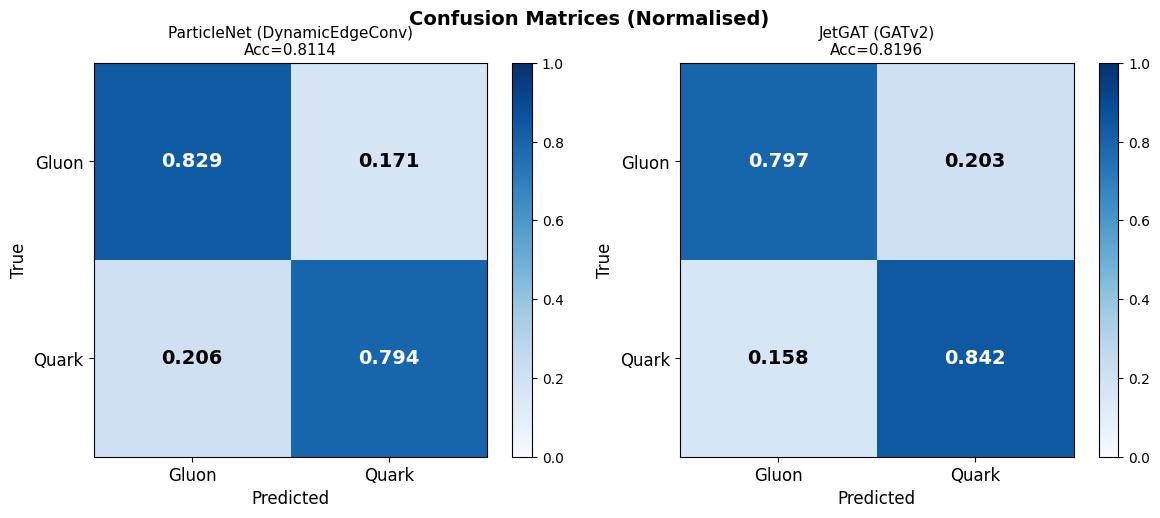

✔ Saved → /content/drive/MyDrive/jet_gnn/results/confusion_matrices.png


In [ ]:
# ── CELL 6: Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices (Normalised)',
             fontsize=14, fontweight='bold')

for ax, (name, cfg) in zip(axes, MODEL_CFGS.items()):
    r  = results[name]
    cm = confusion_matrix(r['labels'], r['preds'], normalize='true')

    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Gluon', 'Quark'], fontsize=12)
    ax.set_yticklabels(['Gluon', 'Quark'], fontsize=12)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(f"{cfg['label']}\nAcc={r['acc']:.4f}", fontsize=11)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:.3f}',
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > 0.5 else 'black')

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/confusion_matrices.png')

In [ ]:
# ── CELL 7: Background rejection table ───────────────────────────────────────
print('=' * 65)
print('BACKGROUND REJECTION TABLE')
print('Physics metric: 1/ε_B at fixed signal efficiency ε_S')
print('=' * 65)
print(f"{'ε_S':>8}  {'ParticleNet 1/ε_B':>20}  {'JetGAT 1/ε_B':>15}")
print('-' * 65)

efficiencies = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for eff in efficiencies:
    row = f'{eff:>8.1f}'
    for name in MODEL_CFGS:
        r   = results[name]
        idx = np.searchsorted(r['tpr'], eff)
        idx = min(idx, len(r['fpr']) - 1)
        fp  = r['fpr'][idx] if r['fpr'][idx] > 0 else 1e-6
        row += f'  {1/fp:>20.1f}'
    print(row)

print('=' * 65)

BACKGROUND REJECTION TABLE
Physics metric: 1/ε_B at fixed signal efficiency ε_S
     ε_S     ParticleNet 1/ε_B     JetGAT 1/ε_B
-----------------------------------------------------------------
     0.2                 111.2                 124.2
     0.3                  66.5                  86.6
     0.4                  48.1                  55.2
     0.5                  29.4                  31.8
     0.6                  18.3                  20.4
     0.7                  10.3                  11.4
     0.8                   5.6                   6.3


In [ ]:
# ── CELL 8: Classification report ────────────────────────────────────────────
for name, cfg in MODEL_CFGS.items():
    r = results[name]
    print(f"\n{cfg['label']}")
    print('-' * 50)
    print(classification_report(
        r['labels'], r['preds'],
        target_names=['Gluon', 'Quark'],
        digits=4
    ))


ParticleNet (DynamicEdgeConv)
--------------------------------------------------
              precision    recall  f1-score   support

       Gluon     0.7991    0.8286    0.8136      7450
       Quark     0.8245    0.7944    0.8092      7550

    accuracy                         0.8114     15000
   macro avg     0.8118    0.8115    0.8114     15000
weighted avg     0.8119    0.8114    0.8114     15000


JetGAT (GATv2)
--------------------------------------------------
              precision    recall  f1-score   support

       Gluon     0.8330    0.7965    0.8143      7450
       Quark     0.8075    0.8424    0.8246      7550

    accuracy                         0.8196     15000
   macro avg     0.8202    0.8194    0.8195     15000
weighted avg     0.8202    0.8196    0.8195     15000



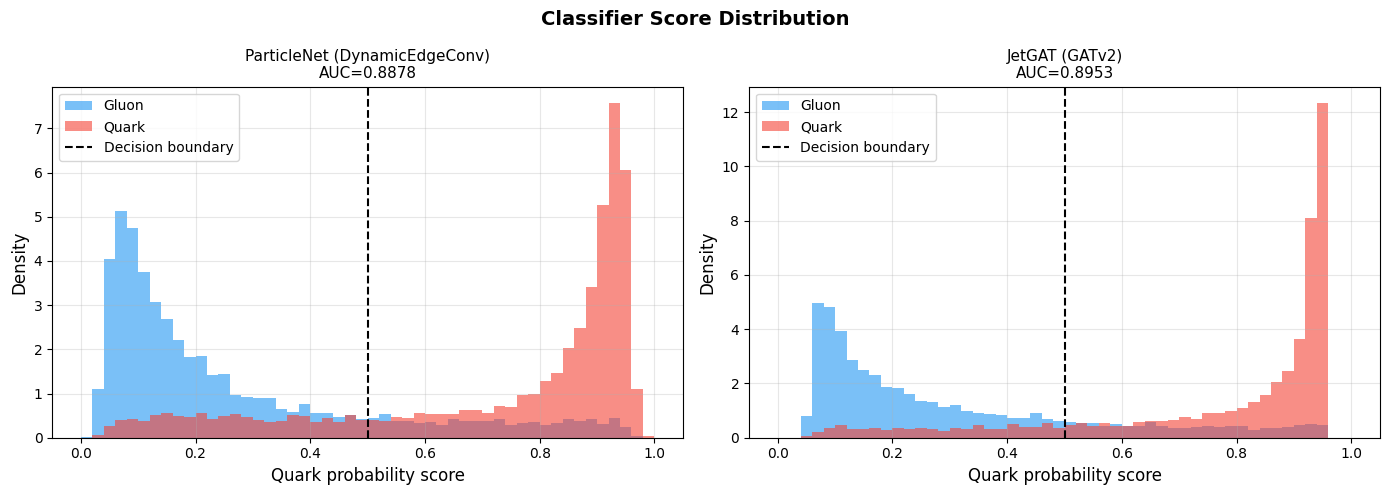

✔ Saved → /content/drive/MyDrive/jet_gnn/results/score_distributions.png


In [ ]:
# ── CELL 9: Score distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classifier Score Distribution',
             fontsize=14, fontweight='bold')

for ax, (name, cfg) in zip(axes, MODEL_CFGS.items()):
    r = results[name]

    quark_scores = r['probs'][r['labels'] == 1]
    gluon_scores = r['probs'][r['labels'] == 0]

    ax.hist(gluon_scores, bins=50, range=(0, 1),
            alpha=0.6, color='#2196F3', label='Gluon',
            density=True)
    ax.hist(quark_scores, bins=50, range=(0, 1),
            alpha=0.6, color='#F44336', label='Quark',
            density=True)

    ax.axvline(x=0.5, color='black', linestyle='--',
               linewidth=1.5, label='Decision boundary')
    ax.set_xlabel('Quark probability score', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f"{cfg['label']}\nAUC={r['auc']:.4f}", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/score_distributions.png')

In [ ]:
# ── CELL 10: Cross-generator test (Herwig) ────────────────────────────────────
print('Loading Herwig jets ...')

X_h, y_h = ef.qg_jets.load(
    num_data  = 20_000,
    pad       = True,
    generator = 'herwig',
    with_bc   = False,
)

print(f'Herwig jets : {X_h.shape}')

herwig_graphs = []
for i, (particles, label) in enumerate(zip(X_h, y_h)):
    g = jet_to_graph(particles)
    if g is not None:
        g.y = torch.tensor([int(label)], dtype=torch.long)
        herwig_graphs.append(g)

print(f'Valid graphs: {len(herwig_graphs):,}')

herwig_results = {}
for name in MODEL_CFGS:
    probs, labels = get_predictions(name, herwig_graphs)
    auc = roc_auc_score(labels, probs)
    acc = ((probs > 0.5).astype(int) == labels).mean()
    fpr, tpr, _ = roc_curve(labels, probs)
    herwig_results[name] = dict(
        probs=probs, labels=labels,
        auc=auc, acc=acc,
        fpr=fpr, tpr=tpr
    )
    print(f'{name}  Herwig AUC={auc:.4f}  Acc={acc:.4f}')

Loading Herwig jets ...
Herwig jets : (20000, 136, 4)
Valid graphs: 20,000
particlenet  Herwig AUC=0.7992  Acc=0.7109
jetgat  Herwig AUC=0.8036  Acc=0.6864


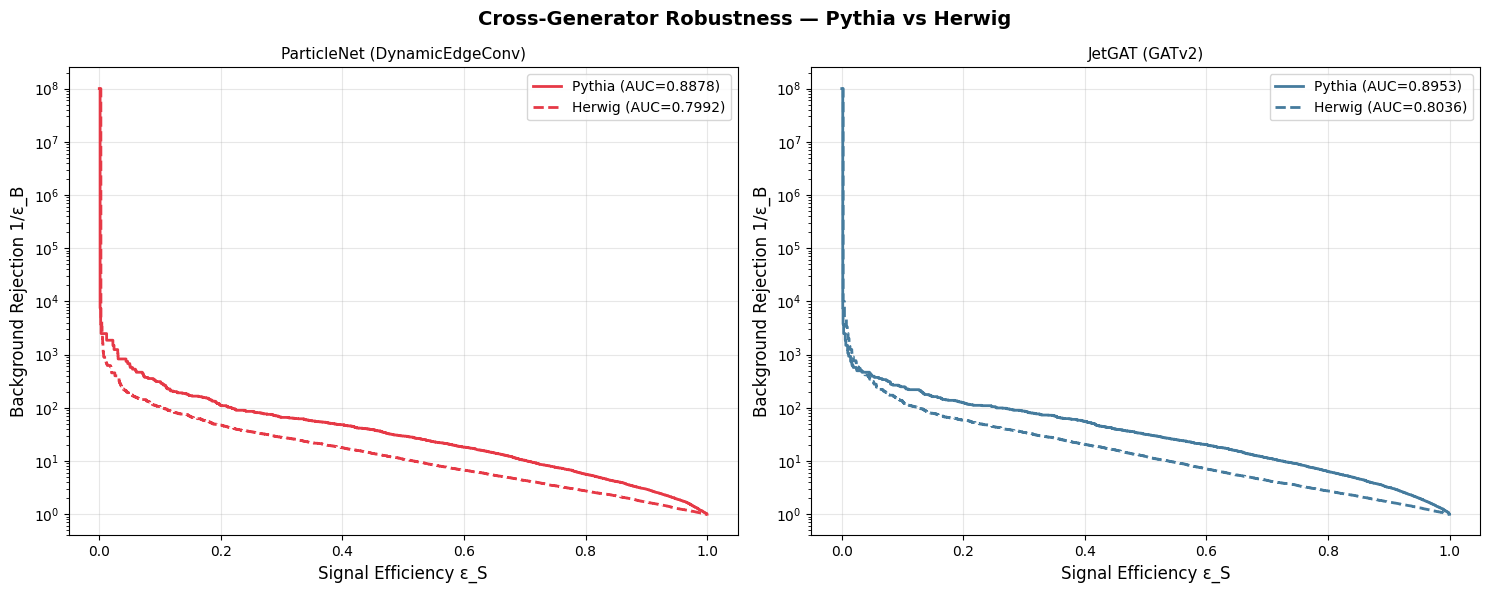

✔ Saved → /content/drive/MyDrive/jet_gnn/results/cross_generator.png


In [ ]:
# ── CELL 11: Cross-generator comparison plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Cross-Generator Robustness — Pythia vs Herwig',
             fontsize=14, fontweight='bold')

for ax, (name, cfg) in zip(axes, MODEL_CFGS.items()):
    r_py = results[name]
    r_hw = herwig_results[name]

    ax.plot(r_py['tpr'], 1.0 / (r_py['fpr'] + 1e-8),
            color=cfg['color'], linewidth=2, linestyle='-',
            label=f"Pythia (AUC={r_py['auc']:.4f})")
    ax.plot(r_hw['tpr'], 1.0 / (r_hw['fpr'] + 1e-8),
            color=cfg['color'], linewidth=2, linestyle='--',
            label=f"Herwig (AUC={r_hw['auc']:.4f})")

    ax.set_xlabel('Signal Efficiency ε_S', fontsize=12)
    ax.set_ylabel('Background Rejection 1/ε_B', fontsize=12)
    ax.set_title(cfg['label'], fontsize=11)
    ax.set_yscale('log')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cross_generator.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/cross_generator.png')

In [ ]:
# ── CELL 12: Final summary table ──────────────────────────────────────────────
print('\n' + '=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)
print(f"{'Metric':<30} {'ParticleNet':>18} {'JetGAT':>18}")
print('-' * 70)

metrics = [
    ('Test AUC (Pythia)',    'auc'),
    ('Test Accuracy',        'acc'),
]

for label, key in metrics:
    pnet_val = results['particlenet'][key]
    gat_val  = results['jetgat'][key]
    diff     = gat_val - pnet_val
    print(f'{label:<30} {pnet_val:>18.4f} {gat_val:>18.4f}  ({diff:+.4f})')

print()
print(f"{'Herwig AUC (cross-gen)':<30} "
      f"{herwig_results['particlenet']['auc']:>18.4f} "
      f"{herwig_results['jetgat']['auc']:>18.4f}  "
      f"({herwig_results['jetgat']['auc']-herwig_results['particlenet']['auc']:+.4f})")

print()

# Load param counts from model
pnet_params = sum(p.numel() for p in build_model('particlenet').parameters())
gat_params  = sum(p.numel() for p in build_model('jetgat').parameters())
print(f"{'Parameters':<30} {pnet_params:>18,} {gat_params:>18,}")
print(f"{'Graph type':<30} {'Dynamic':>18} {'Static':>18}")
print(f"{'Aggregation':<30} {'Unweighted MAX':>18} {'Attention':>18}")

print('=' * 70)

# Save summary to JSON
summary = {
    'particlenet': {
        'test_auc_pythia':  results['particlenet']['auc'],
        'test_acc_pythia':  results['particlenet']['acc'],
        'herwig_auc':       herwig_results['particlenet']['auc'],
        'parameters':       pnet_params,
    },
    'jetgat': {
        'test_auc_pythia':  results['jetgat']['auc'],
        'test_acc_pythia':  results['jetgat']['acc'],
        'herwig_auc':       herwig_results['jetgat']['auc'],
        'parameters':       gat_params,
    }
}

with open(RESULTS_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n✔ All results saved to {RESULTS_DIR}')
print('  roc_curves.png')
print('  training_curves.png')
print('  confusion_matrices.png')
print('  score_distributions.png')
print('  cross_generator.png')
print('  summary.json')


FINAL RESULTS SUMMARY
Metric                                ParticleNet             JetGAT
----------------------------------------------------------------------
Test AUC (Pythia)                          0.8878             0.8953  (+0.0075)
Test Accuracy                              0.8114             0.8196  (+0.0082)

Herwig AUC (cross-gen)                     0.7992             0.8036  (+0.0045)

Parameters                                336,642            369,410
Graph type                                Dynamic             Static
Aggregation                        Unweighted MAX          Attention

✔ All results saved to /content/drive/MyDrive/jet_gnn/results
  roc_curves.png
  training_curves.png
  confusion_matrices.png
  score_distributions.png
  cross_generator.png
  summary.json


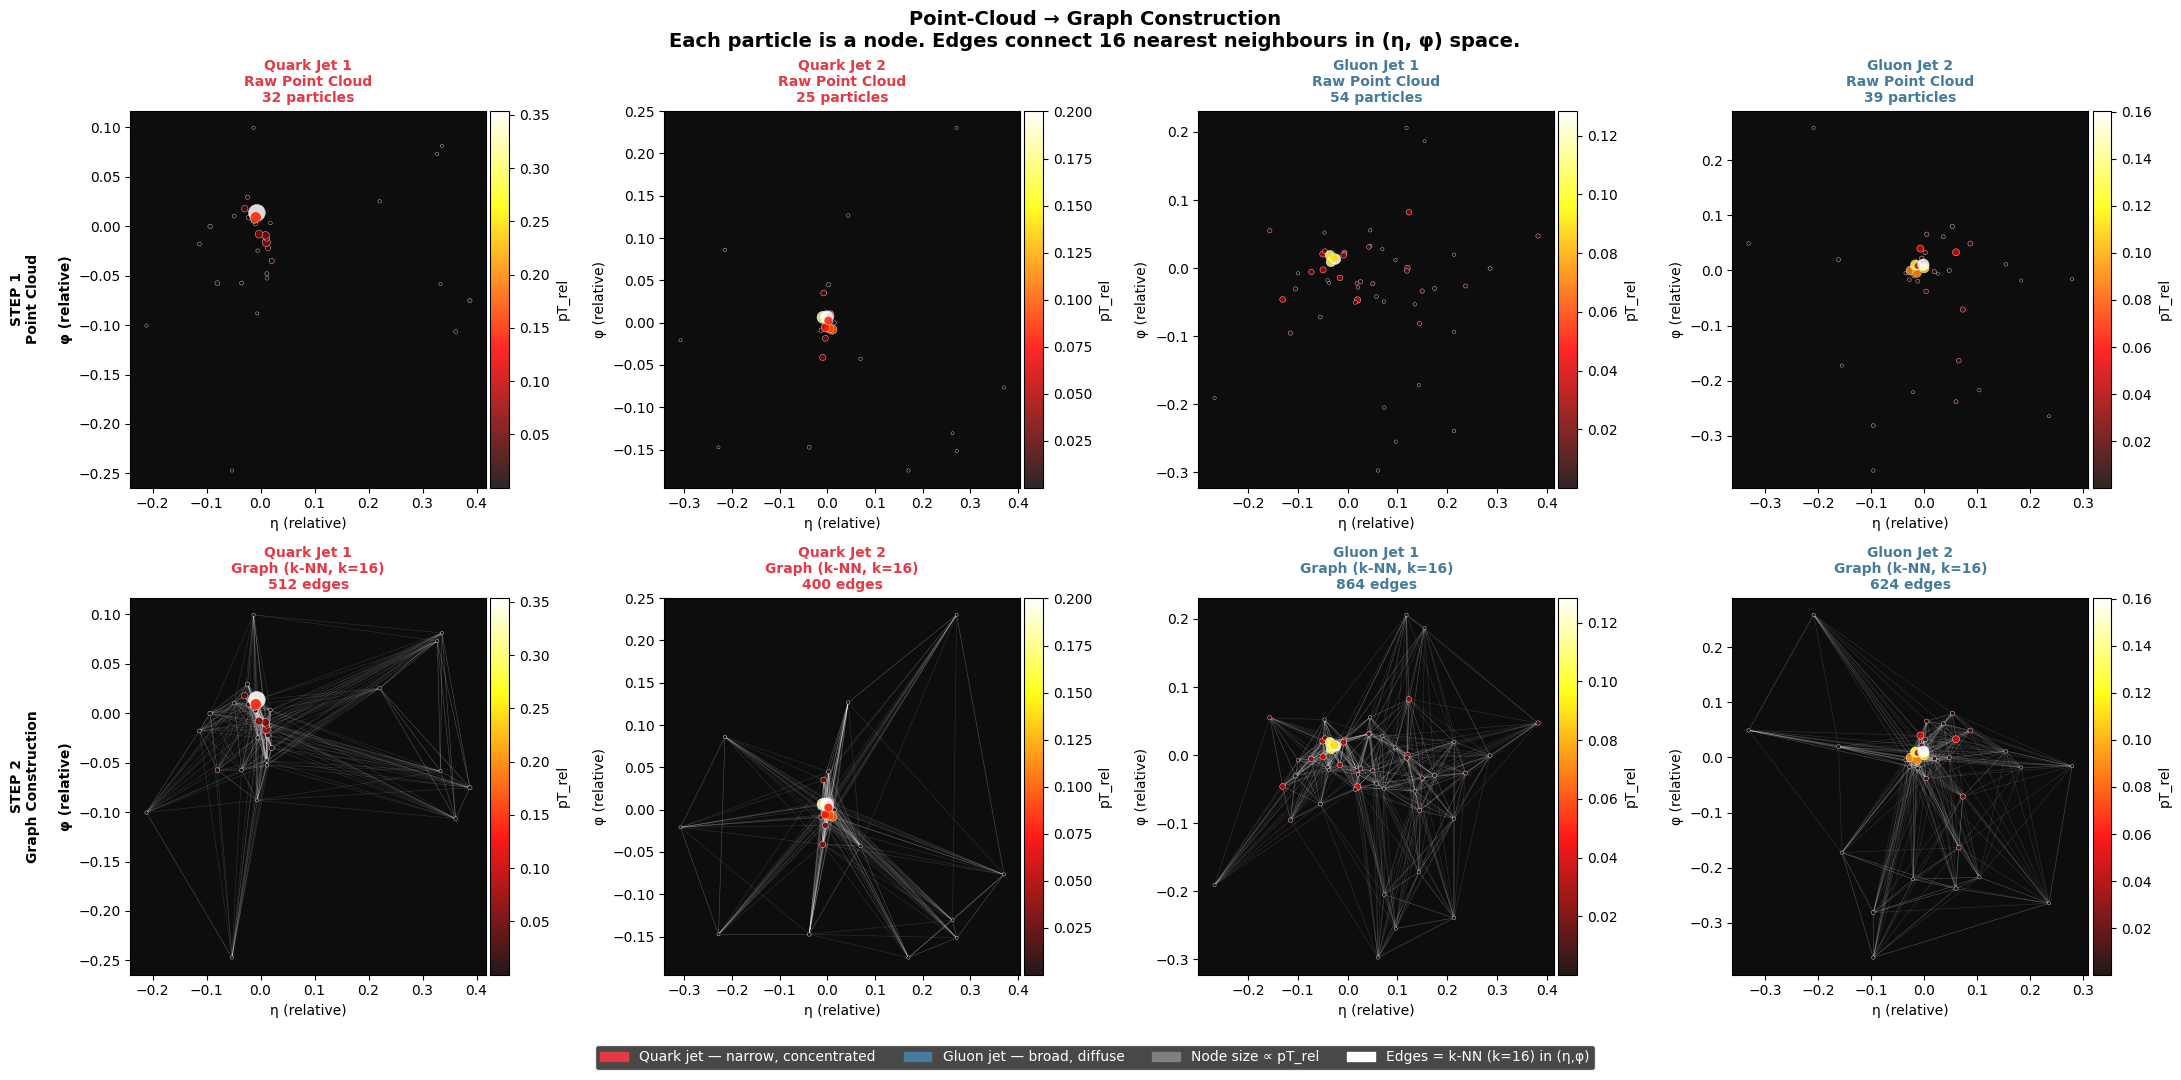

✔ Saved → /content/drive/MyDrive/jet_gnn/results/graph_construction.png


In [ ]:
import sys
import os

if not os.path.exists('/content/jet_gnn'):
    os.symlink('/content/drive/MyDrive/jet_gnn/src', '/content/jet_gnn')

sys.path.insert(0, '/content/jet_gnn')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from data_loader import jet_to_graph

RESULTS_DIR = Path('/content/drive/MyDrive/jet_gnn/results')
RESULTS_DIR.mkdir(exist_ok=True)

# ── Pick 2 quarks and 2 gluons from test data ─────────────────────────────────
quark_jets = [g for g in test_data if g.y.item() == 1][:2]
gluon_jets = [g for g in test_data if g.y.item() == 0][:2]
samples    = quark_jets + gluon_jets
titles     = ['Quark Jet 1', 'Quark Jet 2', 'Gluon Jet 1', 'Gluon Jet 2']
colors     = ['#E63946', '#E63946', '#457B9D', '#457B9D']

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle(
    'Point-Cloud → Graph Construction\n'
    'Each particle is a node. Edges connect 16 nearest neighbours in (η, φ) space.',
    fontsize=14, fontweight='bold'
)

for col, (g, title, color) in enumerate(zip(samples, titles, colors)):

    # ── Node positions ────────────────────────────────────────────────────────
    eta   = g.x[:, 1].numpy()   # eta_rel
    phi   = g.x[:, 2].numpy()   # phi_rel
    pt    = g.x[:, 0].numpy()   # pt_rel
    log_pt = g.x[:, 3].numpy()  # log_pt

    src, dst = g.edge_index.numpy()

    # ── TOP ROW: Point cloud (no edges) ──────────────────────────────────────
    ax = axes[0][col]
    sc = ax.scatter(eta, phi,
                    s     = pt * 400 + 5,
                    c     = pt,
                    cmap  = 'hot',
                    alpha = 0.85,
                    zorder= 2,
                    edgecolors='white',
                    linewidths=0.3)
    ax.set_facecolor('#0d0d0d')
    ax.set_xlabel('η (relative)', fontsize=10)
    ax.set_ylabel('φ (relative)', fontsize=10)
    ax.set_title(f'{title}\nRaw Point Cloud\n'
                 f'{g.x.shape[0]} particles',
                 fontsize=10, color=color, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='pT_rel', pad=0.01)

    # ── BOTTOM ROW: Graph (with edges) ───────────────────────────────────────
    ax = axes[1][col]

    # Draw edges first so nodes appear on top
    for s, d in zip(src, dst):
        ax.plot([eta[s], eta[d]],
                [phi[s], phi[d]],
                color='white', alpha=0.15,
                linewidth=0.4, zorder=1)

    # Draw nodes
    sc = ax.scatter(eta, phi,
                    s     = pt * 400 + 5,
                    c     = pt,
                    cmap  = 'hot',
                    alpha = 0.9,
                    zorder= 2,
                    edgecolors='white',
                    linewidths=0.3)
    ax.set_facecolor('#0d0d0d')
    ax.set_xlabel('η (relative)', fontsize=10)
    ax.set_ylabel('φ (relative)', fontsize=10)
    ax.set_title(f'{title}\nGraph (k-NN, k=16)\n'
                 f'{g.edge_index.shape[1]} edges',
                 fontsize=10, color=color, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='pT_rel', pad=0.01)

# ── Row labels ────────────────────────────────────────────────────────────────
axes[0][0].set_ylabel('STEP 1\nPoint Cloud\n\nφ (relative)',
                       fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('STEP 2\nGraph Construction\n\nφ (relative)',
                       fontsize=10, fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
quark_patch  = mpatches.Patch(color='#E63946', label='Quark jet — narrow, concentrated')
gluon_patch  = mpatches.Patch(color='#457B9D', label='Gluon jet — broad, diffuse')
size_patch   = mpatches.Patch(color='gray',    label='Node size ∝ pT_rel')
edge_patch   = mpatches.Patch(color='white',   label='Edges = k-NN (k=16) in (η,φ)')

fig.legend(handles=[quark_patch, gluon_patch, size_patch, edge_patch],
           loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.01),
           facecolor='#1a1a1a', edgecolor='white',
           labelcolor='white')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(RESULTS_DIR / 'graph_construction.png',
            dpi=150, bbox_inches='tight',
            facecolor='#1a1a1a')
plt.show()
print(f'✔ Saved → {RESULTS_DIR}/graph_construction.png')